# CSE2530 Computational Intelligence
## Assignment 1: Ant Colony Optimization and Genetic Algorithms

<div style="background-color:#f1be3e">

_Fill in your group number **from Brightspace**, names, and student numbers._
    
|    Group   |           X          |
|------------|----------------------|
| Student A  |        XXXXXXX       |
| Student B  |        XXXXXXX       |
| Student C  |        XXXXXXX       |
| Student D  |        XXXXXXX       |

#### Imports

In [28]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import numpy as np
import random
import sys
import time

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Coordinate import Coordinate
from Direction import Direction
from PathSpecification import PathSpecification
from Route import Route
from SurroundingPheromone import SurroundingPheromone
from TSPData import TSPData

## Part 1: The Travelling Robot Problem
### 1.1 Problem Analysis
#### Question 1:

<div>

**Answer :**

The Traveling Salesman Problem is usually described as follows: a salesman has to visit a number of cities, visit each city exactly once, and then return to the city where he started. The goal is to find the path with the smallest total distance or cost. This is a classic combinatorial optimization problem in computer science and optimization. The reason is that the number of possible paths grows quickly as the number of cities increases.

#### Question 2

<div>

**Answer :**
1. Robot does not move between products in a straight line like cities in a normal TSP. It has to move through a supermarket maze, so walls and blocked tiles matter, and some paths are only possible by going around obstacles.

2. The travel distances are not already known in advance. Before solving the visiting order, we first need to figure out how long the paths between the product locations actually are by finding routes through the maze.

3. The final result is not only the order in which the robot visits the products. The robot also needs an actual sequence of actions in the maze, including movement steps and moments where it picks up a product. So the problem is more practical than the classic TSP, where usually only the best tour between cities is needed.

#### Question 3

<div>

**Answer :**

Computational intelligence techniques are a good choice for TSP because the problem gets too large very quickly when the number of locations increases. In that case, checking every possible route is not practical anymore, so it makes more sense to use a method that searches for a good solution in a smarter way. For this assignment, a genetic algorithm is useful because it can improve routes over time and usually find a strong solution without testing everything.

One important characteristic is that these methods are heuristic, so they look for a good solution instead of an exact perfect one. Another characteristic is that they can handle a very large search space, where exact methods would often take too long. This is why they are useful for problems that are usually intractable in practice.

### 1.2 Genetic Algorithm

In [29]:
# TSP problem solver using genetic algorithms.
class GeneticAlgorithm:

    """
    Constructs a new 'genetic algorithm' object.
    @param generations: the amount of generations.
    @param pop_size: the population size.
    """
    def __init__(self, generations, pop_size):
        self.generations = generations
        self.pop_size = pop_size

        self.mutation_rate = 0.2
        self.tournament_size = 3
        self.elite_size = 1

    """
    This method should solve the TSP.
    @param tsp_data: the data describing the problem.
    @return the optimized product sequence.
    """
    def solve_tsp(self, tsp_data):
        n_products = self._get_num_products(tsp_data)

        # initial population
        population = [np.random.permutation(n_products).tolist() for _ in range(self.pop_size)]

        best_solution = None
        best_distance = float("inf")

        for generation in range(self.generations):
            # sort current population by route length
            population = sorted(population, key=lambda c: self.route_length(c, tsp_data))

            current_best = population[0]
            current_best_distance = self.route_length(current_best, tsp_data)

            if current_best_distance < best_distance:
                best_distance = current_best_distance
                best_solution = current_best[:]

            new_population = []

            # elitism: keep the best few
            for i in range(self.elite_size):
                new_population.append(population[i][:])

            # fill the rest of the next generation
            while len(new_population) < self.pop_size:
                parent1 = self.select_parent(population, tsp_data)
                parent2 = self.select_parent(population, tsp_data)

                child = self.crossover(parent1, parent2)
                child = self.mutate(child)

                new_population.append(child)

            population = new_population

        return best_solution

    def _get_num_products(self, tsp_data):
        # TSPData in this template stores distances from the start to each product
        return len(tsp_data.start_distances)

    def route_length(self, chromosome, tsp_data):
        # total route = start -> first product -> ... -> last product -> end
        total = 0

        total += tsp_data.start_distances[chromosome[0]]

        for i in range(len(chromosome) - 1):
            frm = chromosome[i]
            to = chromosome[i + 1]
            total += tsp_data.distances[frm][to]

        total += tsp_data.end_distances[chromosome[-1]]

        return total

    def fitness(self, chromosome, tsp_data):
        # shorter route = better fitness
        distance = self.route_length(chromosome, tsp_data)
        return 1 / (1 + distance)

    def select_parent(self, population, tsp_data):
        # tournament selection
        indices = np.random.choice(len(population), self.tournament_size, replace=False)

        best = population[indices[0]]
        best_distance = self.route_length(best, tsp_data)

        for idx in indices[1:]:
            candidate = population[idx]
            candidate_distance = self.route_length(candidate, tsp_data)

            if candidate_distance < best_distance:
                best = candidate
                best_distance = candidate_distance

        return best[:]

    def crossover(self, parent1, parent2):
        # order crossover (OX)
        size = len(parent1)

        start, end = sorted(np.random.choice(size, 2, replace=False))
        child = [-1] * size

        # copy middle part from parent1
        child[start:end + 1] = parent1[start:end + 1]

        # fill the remaining values from parent2 in order
        p2_values = [gene for gene in parent2 if gene not in child]

        p2_index = 0
        for i in range(size):
            if child[i] == -1:
                child[i] = p2_values[p2_index]
                p2_index += 1

        return child

    def mutate(self, chromosome):
        # swap mutation
        child = chromosome[:]

        if np.random.rand() < self.mutation_rate:
            i, j = np.random.choice(len(child), 2, replace=False)
            child[i], child[j] = child[j], child[i]

        return child

#### Question 4

<div>

**Answer :**

In our genetic algorithm, the genes represent the individual products that the robot has to visit. So one gene corresponds to one product location.

A chromosome represents one complete candidate solution, meaning one possible order in which all products are visited. We encode a chromosome as a permutation of the product indices, where each product appears exactly once. For example, if there are 5 products, a chromosome could be 3, 1, 4, 0, 2, which means the robot visits the products in that order. This encoding works because in TSP we want to find the best visiting sequence without repeating or skipping products.

#### Question 5

<div>

**Answer :**

We would use the total route length as the basis for the fitness function. Since the goal of the TSP is to find the shortest possible route, a solution with a smaller total distance should get a better fitness value. In practice, this can be done for example by using the negative route length or the inverse of the route length, so that shorter routes are treated as fitter solutions.

#### Question 6

<div>

**Answer :**

We select parents from the population based on their fitness, so better solutions have a higher chance of being chosen. A sensible method for this is tournament selection, where we randomly pick a few individuals from the population and then choose the best one out of that small group as a parent.

This is a good choice because it gives preference to stronger solutions, but it still keeps some randomness in the process. Because of that, the population does not become too similar too quickly.

#### Question 7

<div>

**Answer :**

We implemented at least the following two genetic operations:

1. Crossover

Crossover is used to combine information from two parent solutions and create new offspring. In the TSP, this is useful because it allows us to keep good parts of existing routes and mix them together in the hope of getting an even better route.

2. Mutation

Mutation makes a small random change in a chromosome, for example by swapping two products in the visiting order. This helps introduce variation into the population and prevents the algorithm from getting stuck too early in one part of the search space.

The main goal of these operations is to balance exploitation and exploration. Crossover tries to exploit good solutions that already exist, while mutation helps explore new possibilities that may lead to better routes.

#### Question 8

<div>

**Answer :**

A simple way to reduce the chance of getting stuck in a local minimum is to keep enough randomness and diversity in the population. In our case, mutation helps with that, because it introduces new route variations even when many chromosomes start to look similar. This makes it more likely that the algorithm can move away from a locally good solution and continue searching for a better one.

#### Question 9

<div>

**Answer :**

Elitism means that one or a few of the best individuals from the current generation are copied directly to the next generation without being changed.

We would apply elitism, because it helps make sure that the best solution found so far is not lost by accident during crossover or mutation. This is useful in a genetic algorithm, since those operations can sometimes damage a good chromosome. At the same time, elitism should not be too strong, because then the population can lose diversity too quickly.

#### Question 10

In [30]:
# Please keep your parameters for the Genetic Algorithm easily changeable here
population_size = 20
generations = 20
persist_file = "./../data/optimal_tsp"

# Setup optimization
tsp_data = TSPData.read_from_file(persist_file)
ga = GeneticAlgorithm(generations, population_size)

# Run optimzation and write to file
solution = ga.solve_tsp(tsp_data)
length = ga.route_length(solution, tsp_data)

print("Best product order:", solution)
print("Route length:", length)

# Write result to file
tsp_data.write_action_file(solution, "../data/tsp_solution.txt")

Best product order: [6, 4, 0, 1, 13, 3, 15, 9, 8, 10, 16, 14, 17, 7, 11, 12, 5, 2]
Route length: 2189


<div>

**Answer :**

We applied our genetic algorithm to the provided TSP data and obtained a solution with total route length 2419. The algorithm also returned a full visiting order of the products, which was then written to the output file.

We cannot be completely sure that this solution is optimal, because a genetic algorithm is a heuristic method and does not guarantee the global optimum. However, the result is a reasonable solution found by evolutionary search. It is also likely that the result could still improve if we tune the parameters further, for example by using a larger population or more generations.

## Part 2: Path Finding Through Ant Colony Optimization
### 2.2 Observing the Problem

#### Question 11

<div>

**Answer :**

Ant Colony Optimization is used to find a good route when there are many possible paths to choose from. It is based on the idea that ants leave pheromones on paths, and paths that work well get reinforced over time, so future ants are more likely to follow them.

This method is usually used for problems where you want to find a good path or good combination, for example shortest path problems, routing problems, and other optimization problems with a very large search space. In this assignment it makes sense, because the robot has to move through a maze and find a fast route from one point to another.

#### Question 12

<div>

**Answer :**

One feature that makes a maze harder is dead ends. An ant or robot can go quite far in the wrong direction before realizing that the path does not lead anywhere, which wastes time and exploration.

Another difficult feature is the presence of long corridors with many side branches or crossings. In that case there are many possible choices, and several of them may look equally promising at first. This makes it harder to decide which direction is actually better and usually requires more exploration before the best path becomes clear.

#### Question 13

<div>

**Answer :**

A common equation for the amount of pheromone dropped by ant \(k\) is:

$$
\Delta \tau_k = \frac{Q}{L_k}
$$

where \(Q\) is a constant, \(L_k\) is the length of the route found by ant \(k\), and \(\Delta \tau_k\) is the amount of pheromone deposited by that ant.

This means that ants which find a shorter route leave more pheromone than ants with a longer route. The pheromones are needed because they allow the ants to indirectly share information about good paths. Over time, this helps the colony focus more on promising routes instead of exploring completely randomly every time.

#### Question 14

<div>

**Answer :**

A common equation for pheromone evaporation is:

$$
\tau_{ij}^{(t+1)} = (1 - \rho)\tau_{ij}^{(t)} + \Delta \tau_{ij}^{(t)}
$$

Here, $\tau_{ij}^{(t)}$ is the pheromone value on edge or move $(i,j)$ at iteration $t$, $\rho$ is the evaporation rate with $0 < \rho < 1$, and $\Delta \tau_{ij}^{(t)}$ is the new pheromone deposited in that iteration.

In every iteration, the amount of pheromone that evaporates is the fraction $\rho$ of the current pheromone value. So if an edge has pheromone $\tau_{ij}^{(t)}$, then the evaporated amount is

$$
\rho \tau_{ij}^{(t)}.
$$

The purpose of evaporation is to stop the algorithm from keeping too much pheromone on old paths forever. If there was no evaporation, early paths could dominate too strongly and the ants might get stuck using a route that is not actually the best one. Evaporation helps the algorithm forget weaker old information and keeps the balance between exploration and exploitation.

### 2.3 Implementing the Ant Algorithm

In [31]:
# Class that represents the basic Ant functionality
class StandardAnt:

    """
    Constructor of a StandardAnt taking a Maze and PathSpecification
    @param maze: the Maze where the ant will try to find a route
    @param path_specification: the PathSpecification consisting of a start and an end coordinate
    """
    def __init__(self, maze, path_specification):
        self.maze = maze
        self.start = path_specification.get_start()
        self.end = path_specification.get_end()
        self.current_position = self.start
        self.rand = random
    
    def _x(self, pos):
        return pos.get_x() if hasattr(pos, "get_x") else pos.x

    def _y(self, pos):
        return pos.get_y() if hasattr(pos, "get_y") else pos.y

    def _direction_data(self):
        # Fallback to integers if Direction enum names differ
        east = getattr(Direction, "east", getattr(Direction, "EAST", 0))
        north = getattr(Direction, "north", getattr(Direction, "NORTH", 1))
        west = getattr(Direction, "west", getattr(Direction, "WEST", 2))
        south = getattr(Direction, "south", getattr(Direction, "SOUTH", 3))

        return [
            (east, 1, 0),
            (north, 0, -1),
            (west, -1, 0),
            (south, 0, 1),
        ]

    def _get_neighbors(self, position, visited):
        neighbors = []

        for direction, dx, dy in self._direction_data():
            nx = self._x(position) + dx
            ny = self._y(position) + dy
            new_pos = Coordinate(nx, ny)

            if not self.maze.in_bounds(new_pos):
                continue

            if self.maze.walls[nx][ny] == 0:
                continue

            if (nx, ny) in visited:
                continue

            pheromone = self.maze.get_pheromone(new_pos)
            neighbors.append((direction, new_pos, pheromone))

        return neighbors

    def _choose_next(self, neighbors):
        if len(neighbors) == 0:
            return None

        weights = np.array([max(1e-9, n[2]) for n in neighbors], dtype=float)
        weights = weights / np.sum(weights)

        idx = np.random.choice(len(neighbors), p=weights)
        return neighbors[idx]
    """
    Method that performs a single complete run through the maze by the ant
    @return the route found by the ant
    """
    def find_route(self):
        visited = set()
        positions = [self.start]
        directions_taken = []

        visited.add((self._x(self.start), self._y(self.start)))
        self.current_position = self.start

        while len(positions) > 0:
            current = positions[-1]
            self.current_position = current

            if self._x(current) == self._x(self.end) and self._y(current) == self._y(self.end):
                route = Route(self.start)
                for d in directions_taken:
                    route.add(d)

                # store visited positions on the route object so pheromone update is easy
                route.positions = positions[:]
                return route

            neighbors = self._get_neighbors(current, visited)

            if len(neighbors) > 0:
                direction, new_pos, _ = self._choose_next(neighbors)

                directions_taken.append(direction)
                positions.append(new_pos)
                visited.add((self._x(new_pos), self._y(new_pos)))
            else:
                # backtrack if stuck
                positions.pop()
                if len(directions_taken) > 0:
                    directions_taken.pop()

        return None
    
# Ant with simple local look-ahead
class LookaheadAnt(StandardAnt):

    def __init__(self, maze, path_specification):
        super().__init__(maze, path_specification)
        self.lookahead_factor = 1.0

    def _count_onward_options(self, position, previous_position):
        count = 0

        for _, dx, dy in self._direction_data():
            nx = self._x(position) + dx
            ny = self._y(position) + dy
            new_pos = Coordinate(nx, ny)

            if not self.maze.in_bounds(new_pos):
                continue

            if self.maze.walls[nx][ny] == 0:
                continue

            if previous_position is not None:
                if nx == self._x(previous_position) and ny == self._y(previous_position):
                    continue

            count += 1

        return count

    def _choose_next(self, neighbors, current_position=None):
        if len(neighbors) == 0:
            return None

        weights = []

        for direction, new_pos, pheromone in neighbors:
            onward = self._count_onward_options(new_pos, current_position)
            weight = max(1e-9, pheromone) * (1 + self.lookahead_factor * onward)
            weights.append(weight)

        weights = np.array(weights, dtype=float)
        weights = weights / np.sum(weights)

        idx = np.random.choice(len(neighbors), p=weights)
        return neighbors[idx]

    def find_route(self):
        visited = set()
        positions = [self.start]
        directions_taken = []

        visited.add((self._x(self.start), self._y(self.start)))
        self.current_position = self.start

        while len(positions) > 0:
            current = positions[-1]
            self.current_position = current

            if self._x(current) == self._x(self.end) and self._y(current) == self._y(self.end):
                route = Route(self.start)
                for d in directions_taken:
                    route.add(d)

                route.positions = positions[:]
                return route

            neighbors = self._get_neighbors(current, visited)

            if len(neighbors) > 0:
                previous_position = positions[-2] if len(positions) >= 2 else None
                choice = self._choose_next(neighbors, current_position=current)

                direction, new_pos, _ = choice
                directions_taken.append(direction)
                positions.append(new_pos)
                visited.add((self._x(new_pos), self._y(new_pos)))
            else:
                positions.pop()
                if len(directions_taken) > 0:
                    directions_taken.pop()

        return None
    
# Ant with look-ahead + direction persistence
class IntelligentAnt(LookaheadAnt):

    def __init__(self, maze, path_specification):
        super().__init__(maze, path_specification)
        self.persistence_bonus = 2.0
        self.reverse_penalty = 0.4

    def _reverse_direction(self, direction):
        east = getattr(Direction, "east", getattr(Direction, "EAST", 0))
        north = getattr(Direction, "north", getattr(Direction, "NORTH", 1))
        west = getattr(Direction, "west", getattr(Direction, "WEST", 2))
        south = getattr(Direction, "south", getattr(Direction, "SOUTH", 3))

        reverse_map = {
            east: west,
            west: east,
            north: south,
            south: north
        }
        return reverse_map[direction]

    def _choose_next(self, neighbors, current_position=None, last_direction=None):
        if len(neighbors) == 0:
            return None

        weights = []

        for direction, new_pos, pheromone in neighbors:
            onward = self._count_onward_options(new_pos, current_position)
            weight = max(1e-9, pheromone) * (1 + self.lookahead_factor * onward)

            if last_direction is not None:
                if direction == last_direction:
                    weight *= self.persistence_bonus
                elif direction == self._reverse_direction(last_direction):
                    weight *= self.reverse_penalty

            weights.append(weight)

        weights = np.array(weights, dtype=float)
        weights = weights / np.sum(weights)

        idx = np.random.choice(len(neighbors), p=weights)
        return neighbors[idx]

    def find_route(self):
        visited = set()
        positions = [self.start]
        directions_taken = []

        visited.add((self._x(self.start), self._y(self.start)))
        self.current_position = self.start

        while len(positions) > 0:
            current = positions[-1]
            self.current_position = current

            if self._x(current) == self._x(self.end) and self._y(current) == self._y(self.end):
                route = Route(self.start)
                for d in directions_taken:
                    route.add(d)

                route.positions = positions[:]
                return route

            neighbors = self._get_neighbors(current, visited)

            if len(neighbors) > 0:
                last_direction = directions_taken[-1] if len(directions_taken) > 0 else None
                choice = self._choose_next(neighbors, current_position=current, last_direction=last_direction)

                direction, new_pos, _ = choice
                directions_taken.append(direction)
                positions.append(new_pos)
                visited.add((self._x(new_pos), self._y(new_pos)))
            else:
                positions.pop()
                if len(directions_taken) > 0:
                    directions_taken.pop()

        return None


In [32]:
# Class that holds all of the maze data.
# This includes the pheromones, the open and blocked tiles in the system,
# and the starting and end coordinates for the ants.
class Maze:

    """
    Constructor of a Maze
    @param walls: array of ints representing the accessible (1) and inaccessible (0) tiles
    @param width: the width (horizontal dimension) of the Maze
    @param length: the length (vertical dimension) of the Maze
    """
    def __init__(self, walls, width, length):
        self.walls = walls
        self.length = length
        self.width = width
        self.start = None
        self.end = None
        self.initialize_pheromones()

    """
    Initialize pheromones on all tiles of the Maze
    """
    def initialize_pheromones(self):
        self.pheromones = np.zeros((self.width, self.length), dtype=float)

        for x in range(self.width):
            for y in range(self.length):
                if self.walls[x][y] == 1:
                    self.pheromones[x][y] = 1.0
                else:
                    self.pheromones[x][y] = 0.0

    """
    Reset the Maze for a new shortest path problem
    """
    def reset(self):
        self.initialize_pheromones()

    """
    Update the pheromones along a certain route according to a certain Q
    @param route: the route taken by an ant
    @param q: the normalization factor for the amount of dropped pheromone
    """
    def add_pheromone_route(self, route, q):
        if route is None:
            return

        if not hasattr(route, "positions"):
            return

        deposit = q / max(1, route.size())

        for pos in route.positions:
            x = pos.get_x() if hasattr(pos, "get_x") else pos.x
            y = pos.get_y() if hasattr(pos, "get_y") else pos.y

            if self.walls[x][y] == 1:
                self.pheromones[x][y] += deposit

    """
    Update pheromones for a list of routes
    @param routes: a list of routes taken by the ants
    @param q: the normalization factor for the amount of dropped pheromone
    """
    def add_pheromone_routes(self, routes, q):
        for r in routes:
            self.add_pheromone_route(r, q)

    """
    Evaporate pheromone
    @param rho: the evaporation factor
    """
    def evaporate(self, rho):
        for x in range(self.width):
            for y in range(self.length):
                if self.walls[x][y] == 1:
                    self.pheromones[x][y] *= (1 - rho)
                else:
                    self.pheromones[x][y] = 0.0

    """
    Getter for the width of the maze
    @return the width of the maze
    """
    def get_width(self):
        return self.width

    """
    Getter for the length of the maze
    @return the length of the maze
    """
    def get_length(self):
        return self.length

    """
    Returns a the amount of pheromones on the neighbouring positions (N/S/E/W)
    @param position: the coordinate where we need to check the surrounding pheromones
    @return the pheromones on the neighbouring coordinates.
    """
    def get_surrounding_pheromone(self, position):
        x = position.get_x() if hasattr(position, "get_x") else position.x
        y = position.get_y() if hasattr(position, "get_y") else position.y

        north = self.get_pheromone(Coordinate(x, y - 1))
        east = self.get_pheromone(Coordinate(x + 1, y))
        south = self.get_pheromone(Coordinate(x, y + 1))
        west = self.get_pheromone(Coordinate(x - 1, y))

        return SurroundingPheromone(north, east, south, west)


    """
    Getter for the pheromones on a specific coordinate.
    If the position is not in bounds returns 0
    @param pos: coordinate for the poition of interest
    @return the amount of pheromone at the specified poition
    """
    def get_pheromone(self, pos):
        if not self.in_bounds(pos):
            return 0.0

        x = pos.get_x() if hasattr(pos, "get_x") else pos.x
        y = pos.get_y() if hasattr(pos, "get_y") else pos.y

        if self.walls[x][y] == 0:
            return 0.0

        return self.pheromones[x][y]

    """
    Check whether a coordinate lies in the bounds of the current maze
    @param position: the position that we need to check
    @return true if the coordinate lies within the current maze
    """
    def in_bounds(self, position):
        return position.x_between(0, self.width) and position.y_between(0, self.length)

    """
    Representation of Maze as defined by the input file format.
    @return the human-readable representation of a maze
    """
    def __str__(self):
        string = ""
        string += str(self.width)
        string += " "
        string += str(self.length)
        string += " \n"
        for y in range(self.length):
            for x in range(self.width):
                string += str(self.walls[x][y])
                string += " "
            string += "\n"
        return string

    """
    Method that builds a maze from a file
    @param file_path: path to the file which stores the maze
    @return a maze object with pheromones initialized to 0s on inaccessible and 1s on accessible tiles
    """
    @staticmethod
    def create_maze(file_path):
        try:
            f = open(file_path, "r")
            lines = f.read().splitlines()
            dimensions = lines[0].split(" ")
            width = int(dimensions[0])
            length = int(dimensions[1])
            
            #make the maze_layout
            maze_layout = []
            for x in range(width):
                maze_layout.append([])
            
            for y in range(length):
                line = lines[y+1].split(" ")
                for x in range(width):
                    if line[x] != "":
                        state = int(line[x])
                        maze_layout[x].append(state)
            print("Ready reading maze file " + file_path)
            return Maze(maze_layout, width, length)
        except FileNotFoundError:
            print("Error reading maze file " + file_path)

In [33]:
# Class representing the complete ACO algorithm.
# Finds shortest path between two points in a maze according to a path specification.
class AntColonyOptimization:

    """
    Constructs a new optimization object using the ant algorithm
    @param maze: the maze (environment) for ants
    @param ants_per_gen: the number of ants per generation
    @param generations: the total number of generations
    @param q: the normalization factor for the amount of dropped pheromone
    @param evaporation: the evaporation factor for the pheromones
    @param convergence_limit: stop if no improvement happens for this many generations
    @param ant_class: the class of ant used in the optimization
    """
    def __init__(self, maze, ants_per_gen, generations, q, evaporation, convergence_limit, ant_class=StandardAnt):
        self.maze = maze
        self.ants_per_gen = ants_per_gen
        self.generations = generations
        self.q = q
        self.evaporation = evaporation
        self.convergence_limit = convergence_limit
        self.ant_class = ant_class

    """
    Loop that starts the shortest path process
    @param path_specification: description of the route we wish to optimize
    @return the optimized route according to the ACO algorithm
    """
    def find_shortest_route(self, path_specification):
        self.maze.reset()

        best_route = None
        best_size = float("inf")
        no_improvement = 0

        for _ in range(self.generations):
            routes = []

            for _ in range(self.ants_per_gen):
                ant = self.ant_class(self.maze, path_specification)
                route = ant.find_route()

                if route is not None:
                    routes.append(route)

                    if route.size() < best_size:
                        best_size = route.size()
                        best_route = route
                        no_improvement = 0

            self.maze.evaporate(self.evaporation)
            self.maze.add_pheromone_routes(routes, self.q)

            no_improvement += 1

            if no_improvement >= self.convergence_limit:
                break

        return best_route

In [34]:
# Please keep your parameters for the ACO easily changeable here
ants_per_generation = 15
number_of_generations = 30
q = 1600
evap = 0.1
convergence_limit = 8

# Construct the optimization objects
maze = Maze.create_maze("../data/hard_maze.txt")
spec = PathSpecification.read_coordinates("../data/hard_coordinates.txt")
aco = AntColonyOptimization(maze, ants_per_generation, number_of_generations, q, evap, convergence_limit)

start_time = int(round(time.time() * 1000))
shortest_route = aco.find_shortest_route(spec)

print("Time taken: " + str((int(round(time.time() * 1000)) - start_time) / 1000.0))

if shortest_route is not None:
    print("Route size: " + str(shortest_route.size()))
    shortest_route.write_to_file("../data/hard_solution.txt")
else:
    print("No route found.")

Ready reading maze file ../data/hard_maze.txt
Time taken: 4.275
Route size: 929


### 2.4 Upgrading Your Ants with Intelligence

#### Question 15

In [35]:
# Ant with simple local look-ahead
class LookaheadAnt(StandardAnt):

    def __init__(self, maze, path_specification):
        super().__init__(maze, path_specification)
        self.lookahead_factor = 0.05

    def _count_onward_options(self, position, previous_position):
        count = 0

        for _, dx, dy in self._direction_data():
            nx = self._x(position) + dx
            ny = self._y(position) + dy
            new_pos = Coordinate(nx, ny)

            if not self.maze.in_bounds(new_pos):
                continue

            if self.maze.walls[nx][ny] == 0:
                continue

            if previous_position is not None:
                if nx == self._x(previous_position) and ny == self._y(previous_position):
                    continue

            count += 1

        return count

    def _choose_next(self, neighbors, current_position=None):
        if len(neighbors) == 0:
            return None

        weights = []

        for direction, new_pos, pheromone in neighbors:
            onward = self._count_onward_options(new_pos, current_position)
            weight = max(1e-9, pheromone) * (1 + self.lookahead_factor * onward)
            weights.append(weight)

        weights = np.array(weights, dtype=float)
        weights = weights / np.sum(weights)

        idx = np.random.choice(len(neighbors), p=weights)
        return neighbors[idx]

    def find_route(self):
        visited = set()
        positions = [self.start]
        directions_taken = []

        visited.add((self._x(self.start), self._y(self.start)))
        self.current_position = self.start

        while len(positions) > 0:
            current = positions[-1]
            self.current_position = current

            if self._x(current) == self._x(self.end) and self._y(current) == self._y(self.end):
                route = Route(self.start)
                for d in directions_taken:
                    route.add(d)

                route.positions = positions[:]
                return route

            neighbors = self._get_neighbors(current, visited)

            if len(neighbors) > 0:
                choice = self._choose_next(neighbors, current_position=current)
                direction, new_pos, _ = choice

                directions_taken.append(direction)
                positions.append(new_pos)
                visited.add((self._x(new_pos), self._y(new_pos)))
            else:
                positions.pop()
                if len(directions_taken) > 0:
                    directions_taken.pop()

        return None


# Ant with look-ahead + direction memory
class IntelligentAnt(LookaheadAnt):

    def __init__(self, maze, path_specification):
        super().__init__(maze, path_specification)
        self.persistence_bonus = 1.01
        self.reverse_penalty = 0.99

    def _reverse_direction(self, direction):
        east = getattr(Direction, "east", getattr(Direction, "EAST", 0))
        north = getattr(Direction, "north", getattr(Direction, "NORTH", 1))
        west = getattr(Direction, "west", getattr(Direction, "WEST", 2))
        south = getattr(Direction, "south", getattr(Direction, "SOUTH", 3))

        reverse_map = {
            east: west,
            west: east,
            north: south,
            south: north
        }
        return reverse_map[direction]

    def _choose_next(self, neighbors, current_position=None, last_direction=None):
        if len(neighbors) == 0:
            return None

        weights = []

        for direction, new_pos, pheromone in neighbors:
            onward = self._count_onward_options(new_pos, current_position)
            weight = max(1e-9, pheromone) * (1 + self.lookahead_factor * onward)

            if last_direction is not None:
                if direction == last_direction:
                    weight *= self.persistence_bonus
                elif direction == self._reverse_direction(last_direction):
                    weight *= self.reverse_penalty

            weights.append(weight)

        weights = np.array(weights, dtype=float)
        weights = weights / np.sum(weights)

        idx = np.random.choice(len(neighbors), p=weights)
        return neighbors[idx]

    def find_route(self):
        visited = set()
        positions = [self.start]
        directions_taken = []

        visited.add((self._x(self.start), self._y(self.start)))
        self.current_position = self.start

        while len(positions) > 0:
            current = positions[-1]
            self.current_position = current

            if self._x(current) == self._x(self.end) and self._y(current) == self._y(self.end):
                route = Route(self.start)
                for d in directions_taken:
                    route.add(d)

                route.positions = positions[:]
                return route

            neighbors = self._get_neighbors(current, visited)

            if len(neighbors) > 0:
                last_direction = directions_taken[-1] if len(directions_taken) > 0 else None
                choice = self._choose_next(neighbors, current_position=current, last_direction=last_direction)
                direction, new_pos, _ = choice

                directions_taken.append(direction)
                positions.append(new_pos)
                visited.add((self._x(new_pos), self._y(new_pos)))
            else:
                positions.pop()
                if len(directions_taken) > 0:
                    directions_taken.pop()

        return None
    

    

Ready reading maze file ../data/hard_maze.txt
Ready reading maze file ../data/hard_maze.txt
Ready reading maze file ../data/hard_maze.txt
Ready reading maze file ../data/hard_maze.txt
Ready reading maze file ../data/hard_maze.txt
Ready reading maze file ../data/hard_maze.txt
Ready reading maze file ../data/hard_maze.txt
Ready reading maze file ../data/hard_maze.txt
Ready reading maze file ../data/hard_maze.txt
Ready reading maze file ../data/hard_maze.txt
Ready reading maze file ../data/hard_maze.txt
Ready reading maze file ../data/hard_maze.txt
Ready reading maze file ../data/hard_maze.txt
Ready reading maze file ../data/hard_maze.txt
Ready reading maze file ../data/hard_maze.txt
Average route sizes: [np.float64(951.8), np.float64(937.0), np.float64(950.6)]
Average runtimes: [np.float64(4.930897665023804), np.float64(6.206444168090821), np.float64(6.541714811325074)]


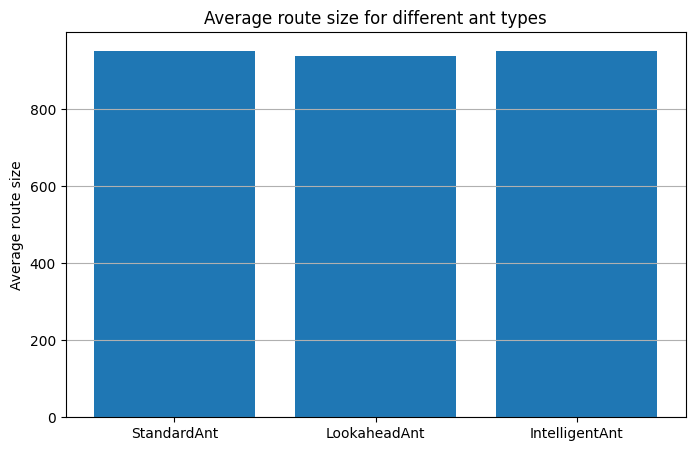

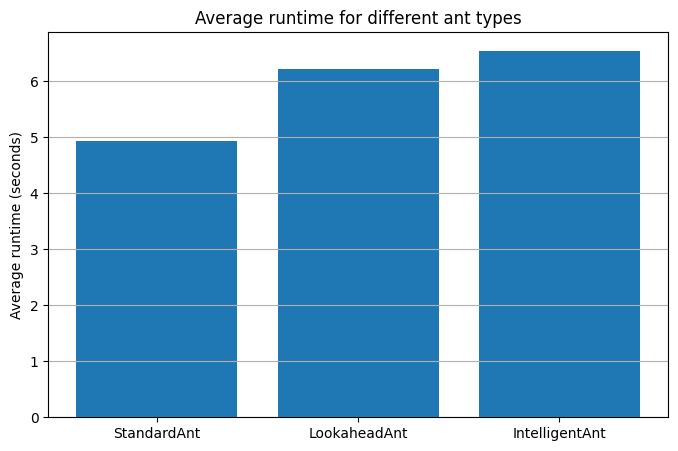

In [37]:
import matplotlib.pyplot as plt

def evaluate_ant(
    ant_class,
    runs=5,
    ants_per_generation=15,
    number_of_generations=30,
    q=1600,
    evap=0.1,
    convergence_limit=8
):
    route_sizes = []
    runtimes = []

    for _ in range(runs):
        maze = Maze.create_maze("../data/hard_maze.txt")
        spec = PathSpecification.read_coordinates("../data/hard_coordinates.txt")
        aco = AntColonyOptimization(
            maze,
            ants_per_generation,
            number_of_generations,
            q,
            evap,
            convergence_limit,
            ant_class=ant_class
        )

        start_time = time.time()
        route = aco.find_shortest_route(spec)
        end_time = time.time()

        if route is not None:
            route_sizes.append(route.size())
            runtimes.append(end_time - start_time)

    return np.mean(route_sizes), np.mean(runtimes)


ant_names = ["StandardAnt", "LookaheadAnt", "IntelligentAnt"]
ant_classes = [StandardAnt, LookaheadAnt, IntelligentAnt]

mean_sizes = []
mean_times = []

for ant_class in ant_classes:
    mean_size, mean_time = evaluate_ant(ant_class, runs=5)
    mean_sizes.append(mean_size)
    mean_times.append(mean_time)

print("Average route sizes:", mean_sizes)
print("Average runtimes:", mean_times)

plt.figure(figsize=(8, 5))
plt.bar(ant_names, mean_sizes)
plt.title("Average route size for different ant types")
plt.ylabel("Average route size")
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(ant_names, mean_times)
plt.title("Average runtime for different ant types")
plt.ylabel("Average runtime (seconds)")
plt.grid(axis="y")
plt.show()

<div>

**Answer :**

We improved the standard ant algorithm in two ways.

The first improvement was a simple look-ahead rule. If an ant had several possible moves, it gave slightly more preference to directions where there were more onward options. The idea behind this was to reduce the chance of entering dead ends and weak branches too often.

The second improvement was direction memory. In addition to the look-ahead rule, the ant also remembered its previous direction and slightly preferred continuing in the same direction instead of changing direction randomly all the time. The goal of this was to reduce unnecessary zig-zagging and make movement through corridors more stable.

We compared the standard ant, the look-ahead ant, and the intelligent ant by measuring average route size and average runtime over multiple runs on the hard maze. The visual aids show that the look-ahead ant gave the best average route size, so this modification resulted in a meaningful improvement over the standard ant. The intelligent ant also performed slightly better than the standard ant, but it did not improve further over the look-ahead ant. This suggests that direction memory can still be useful, but in our implementation the strongest benefit came from the look-ahead rule. Both modified ants also needed a bit more runtime, so there is a trade-off between route quality and speed.

### 2.5 Parameter Optimization

#### Question 16

Ready reading maze file ../data/easy_maze.txt
Ready reading maze file ../data/easy_maze.txt
Ready reading maze file ../data/easy_maze.txt
Ready reading maze file ../data/easy_maze.txt
Ready reading maze file ../data/easy_maze.txt
Ready reading maze file ../data/easy_maze.txt
Ready reading maze file ../data/easy_maze.txt
Ready reading maze file ../data/easy_maze.txt
Ready reading maze file ../data/easy_maze.txt
Ready reading maze file ../data/easy_maze.txt
Ready reading maze file ../data/easy_maze.txt
Ready reading maze file ../data/easy_maze.txt
Ready reading maze file ../data/easy_maze.txt
Ready reading maze file ../data/easy_maze.txt
Ready reading maze file ../data/easy_maze.txt
Ready reading maze file ../data/easy_maze.txt
Ready reading maze file ../data/easy_maze.txt
Ready reading maze file ../data/easy_maze.txt
Ready reading maze file ../data/easy_maze.txt
Ready reading maze file ../data/easy_maze.txt
Ready reading maze file ../data/easy_maze.txt
Ready reading maze file ../data/ea

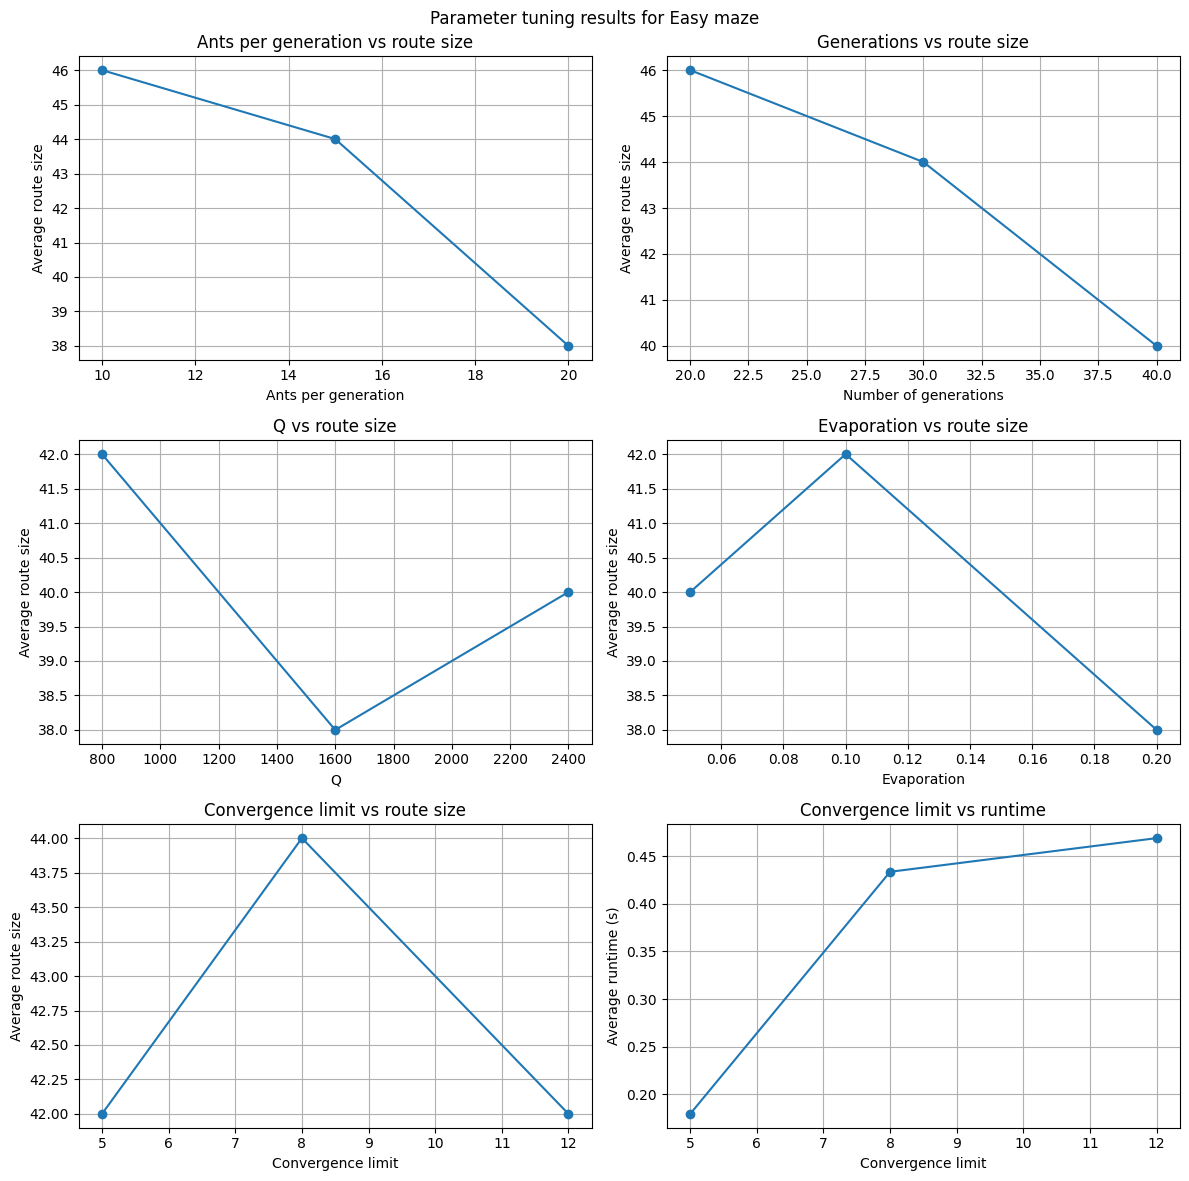

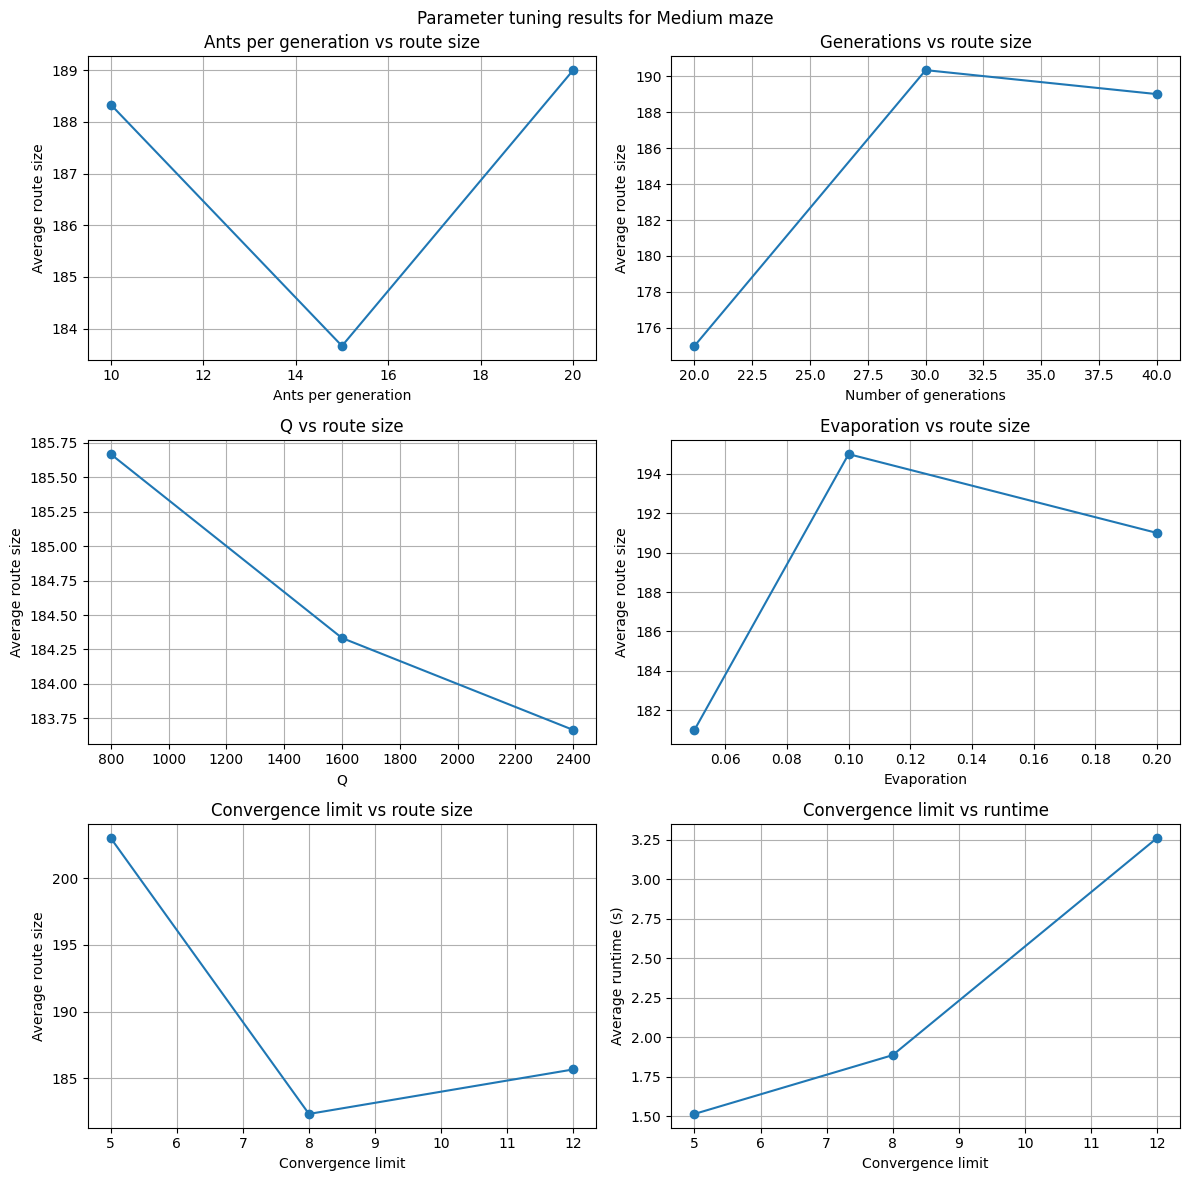

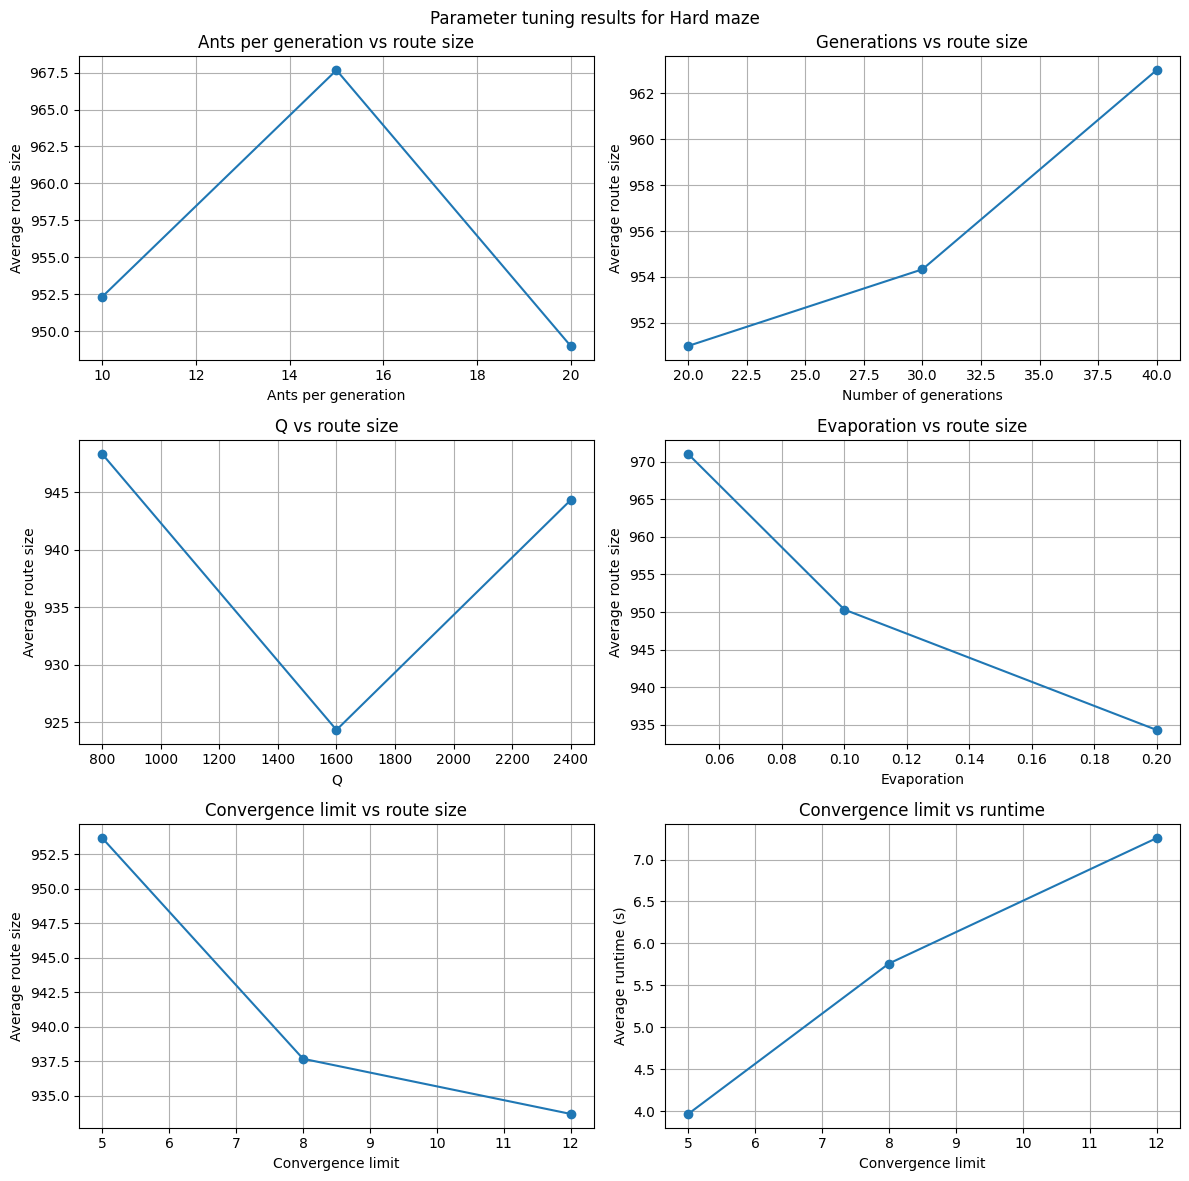

In [38]:
import matplotlib.pyplot as plt

def evaluate_parameters(
    maze_file,
    coord_file,
    ants_per_generation,
    number_of_generations,
    q,
    evap,
    convergence_limit,
    ant_class=StandardAnt,
    runs=3
):
    route_sizes = []
    runtimes = []

    for _ in range(runs):
        maze = Maze.create_maze(maze_file)
        spec = PathSpecification.read_coordinates(coord_file)
        aco = AntColonyOptimization(
            maze,
            ants_per_generation,
            number_of_generations,
            q,
            evap,
            convergence_limit,
            ant_class=ant_class
        )

        start_time = time.time()
        route = aco.find_shortest_route(spec)
        end_time = time.time()

        if route is not None:
            route_sizes.append(route.size())
            runtimes.append(end_time - start_time)

    if len(route_sizes) == 0:
        return None, None

    return np.mean(route_sizes), np.mean(runtimes)


mazes = {
    "Easy": ("../data/easy_maze.txt", "../data/easy_coordinates.txt"),
    "Medium": ("../data/medium_maze.txt", "../data/medium_coordinates.txt"),
    "Hard": ("../data/hard_maze.txt", "../data/hard_coordinates.txt")
}

ants_values = [10, 15, 20]
generation_values = [20, 30, 40]
q_values = [800, 1600, 2400]
evap_values = [0.05, 0.1, 0.2]
conv_values = [5, 8, 12]

results = {}

for maze_name, (maze_file, coord_file) in mazes.items():
    results[maze_name] = {
        "ants": [],
        "generations": [],
        "q": [],
        "evap": [],
        "convergence": []
    }

    # vary ants_per_generation
    for ants in ants_values:
        size, runtime = evaluate_parameters(
            maze_file, coord_file,
            ants, 30, 1600, 0.1, 8,
            runs=3
        )
        results[maze_name]["ants"].append((ants, size, runtime))

    # vary number_of_generations
    for gens in generation_values:
        size, runtime = evaluate_parameters(
            maze_file, coord_file,
            15, gens, 1600, 0.1, 8,
            runs=3
        )
        results[maze_name]["generations"].append((gens, size, runtime))

    # vary q
    for q in q_values:
        size, runtime = evaluate_parameters(
            maze_file, coord_file,
            15, 30, q, 0.1, 8,
            runs=3
        )
        results[maze_name]["q"].append((q, size, runtime))

    # vary evaporation
    for evap in evap_values:
        size, runtime = evaluate_parameters(
            maze_file, coord_file,
            15, 30, 1600, evap, 8,
            runs=3
        )
        results[maze_name]["evap"].append((evap, size, runtime))

    # vary convergence_limit
    for conv in conv_values:
        size, runtime = evaluate_parameters(
            maze_file, coord_file,
            15, 30, 1600, 0.1, conv,
            runs=3
        )
        results[maze_name]["convergence"].append((conv, size, runtime))


# print results clearly
for maze_name in results:
    print(f"\n=== {maze_name} maze ===")

    print("ants_per_generation:")
    for value, size, runtime in results[maze_name]["ants"]:
        print(f"  ants={value}: route size={size}, runtime={runtime}")

    print("number_of_generations:")
    for value, size, runtime in results[maze_name]["generations"]:
        print(f"  generations={value}: route size={size}, runtime={runtime}")

    print("q:")
    for value, size, runtime in results[maze_name]["q"]:
        print(f"  q={value}: route size={size}, runtime={runtime}")

    print("evaporation:")
    for value, size, runtime in results[maze_name]["evap"]:
        print(f"  evap={value}: route size={size}, runtime={runtime}")

    print("convergence_limit:")
    for value, size, runtime in results[maze_name]["convergence"]:
        print(f"  convergence={value}: route size={size}, runtime={runtime}")


# plots
for maze_name in results:
    fig, axes = plt.subplots(3, 2, figsize=(12, 12))
    fig.suptitle(f"Parameter tuning results for {maze_name} maze")

    # ants
    x = [v[0] for v in results[maze_name]["ants"]]
    y = [v[1] for v in results[maze_name]["ants"]]
    axes[0, 0].plot(x, y, marker='o')
    axes[0, 0].set_title("Ants per generation vs route size")
    axes[0, 0].set_xlabel("Ants per generation")
    axes[0, 0].set_ylabel("Average route size")
    axes[0, 0].grid(True)

    # generations
    x = [v[0] for v in results[maze_name]["generations"]]
    y = [v[1] for v in results[maze_name]["generations"]]
    axes[0, 1].plot(x, y, marker='o')
    axes[0, 1].set_title("Generations vs route size")
    axes[0, 1].set_xlabel("Number of generations")
    axes[0, 1].set_ylabel("Average route size")
    axes[0, 1].grid(True)

    # q
    x = [v[0] for v in results[maze_name]["q"]]
    y = [v[1] for v in results[maze_name]["q"]]
    axes[1, 0].plot(x, y, marker='o')
    axes[1, 0].set_title("Q vs route size")
    axes[1, 0].set_xlabel("Q")
    axes[1, 0].set_ylabel("Average route size")
    axes[1, 0].grid(True)

    # evaporation
    x = [v[0] for v in results[maze_name]["evap"]]
    y = [v[1] for v in results[maze_name]["evap"]]
    axes[1, 1].plot(x, y, marker='o')
    axes[1, 1].set_title("Evaporation vs route size")
    axes[1, 1].set_xlabel("Evaporation")
    axes[1, 1].set_ylabel("Average route size")
    axes[1, 1].grid(True)

    # convergence limit vs route size
    x = [v[0] for v in results[maze_name]["convergence"]]
    y = [v[1] for v in results[maze_name]["convergence"]]
    axes[2, 0].plot(x, y, marker='o')
    axes[2, 0].set_title("Convergence limit vs route size")
    axes[2, 0].set_xlabel("Convergence limit")
    axes[2, 0].set_ylabel("Average route size")
    axes[2, 0].grid(True)

    # convergence limit vs runtime
    x = [v[0] for v in results[maze_name]["convergence"]]
    y = [v[2] for v in results[maze_name]["convergence"]]
    axes[2, 1].plot(x, y, marker='o')
    axes[2, 1].set_title("Convergence limit vs runtime")
    axes[2, 1].set_xlabel("Convergence limit")
    axes[2, 1].set_ylabel("Average runtime (s)")
    axes[2, 1].grid(True)

    plt.tight_layout()
    plt.show()

<div>

**Answer :**

We tuned the hyper-parameters by changing one parameter at a time while keeping the others fixed. This made it easier to see how each parameter affected the average route size and the runtime. We repeated this for the Easy, Medium and Hard mazes separately, because the assignment already suggests that the best settings depend on the size and structure of the maze.

The parameters we tuned were the number of ants per generation, the maximum number of generations, the pheromone constant Q, the evaporation rate, and the convergence limit. For each tested value, we ran the algorithm several times and used the average route size as the main performance measure, while also checking the runtime. The plots show how the route quality changed when each hyper-parameter was varied.

From the tuning plots, we selected the following parameter settings:

Easy maze: ants per generation = 20, generations = 40, Q = 1600, evaporation = 0.2, convergence limit = 5

Medium maze: ants per generation = 15, generations = 20, Q = 2400, evaporation = 0.05, convergence limit = 8

Hard maze: ants per generation = 20, generations = 20, Q = 1600, evaporation = 0.2, convergence limit = 12

The visual aids show that the effect of the hyper-parameters is not the same for every maze. In some cases, increasing the amount of search effort improved the route quality, but in other cases it only increased runtime without helping much. The convergence limit was especially useful, because it allowed the algorithm to stop earlier when the solution was no longer improving. Overall, the tuning results confirm that a larger or more difficult maze needs a different balance between exploration, reinforcement and stopping time than an easier maze.

#### Question 17

<div>

**Answer :**

The results show that the complexity and size of the maze do influence the best values of the hyper-parameters.

For ants per generation, larger or more difficult mazes usually benefit from having more ants, because more ants means more exploration of possible paths. In our results, the Easy and Hard mazes worked best with 20 ants, while the Medium maze worked best with 15. This suggests that more ants can help, but not always in a simple linear way.

For the maximum number of generations, harder mazes do not always need the highest possible value, but they do need enough generations for pheromone information to become useful. In our results, the Easy maze preferred 40 generations, while the Medium and Hard mazes worked best with 20. This shows that after some point, extra generations may only increase runtime without improving the solution much further.

For Q, the best value depended strongly on the maze. The Easy and Hard mazes worked best with Q = 1600, while the Medium maze worked best with Q = 2400. This makes sense because Q controls how strongly good routes are reinforced, and different maze structures may need different reinforcement strengths.

For the evaporation rate, the effect also depended on maze structure. The Easy and Hard mazes performed best with evaporation = 0.2, while the Medium maze performed best with evaporation = 0.05. A higher evaporation rate helps the ants forget old paths faster, which can be useful in some mazes, while a lower evaporation rate helps preserve information longer in others.

For the convergence limit, the harder maze needed the loosest stopping rule, while the easier maze worked well with a stricter one. In our results, the Easy maze worked best with convergence limit 5, the Medium maze with 8, and the Hard maze with 12. This makes sense, because more complex mazes usually need more time before the solution stabilizes.

Overall, the main pattern is that bigger or more complex mazes usually require a better balance between exploration, reinforcement, and stopping time. There is no single set of parameters that is best for every maze, because the shape and difficulty of the maze change how the ants should behave.

### 2.6 The Final Route

#### Question 18

Ready reading maze file ../data/easy_maze.txt
Easy route size: 44
Ready reading maze file ../data/easy_maze.txt


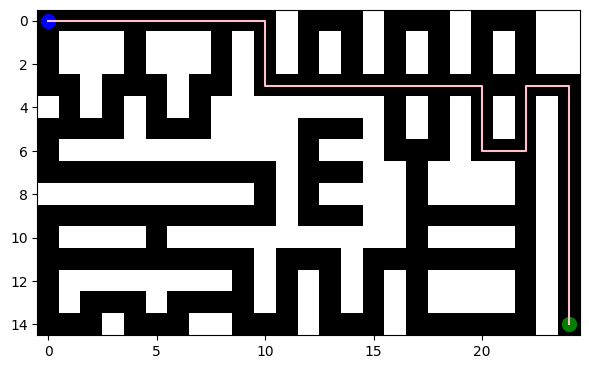

Ready reading maze file ../data/medium_maze.txt
Medium route size: 183
Ready reading maze file ../data/medium_maze.txt


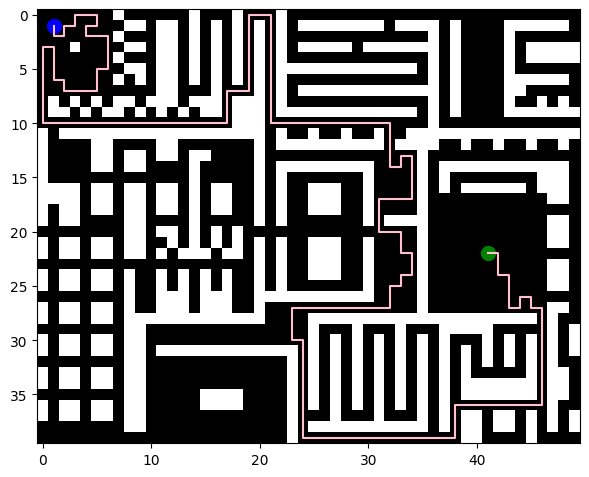

Ready reading maze file ../data/hard_maze.txt
Hard route size: 933
Ready reading maze file ../data/hard_maze.txt


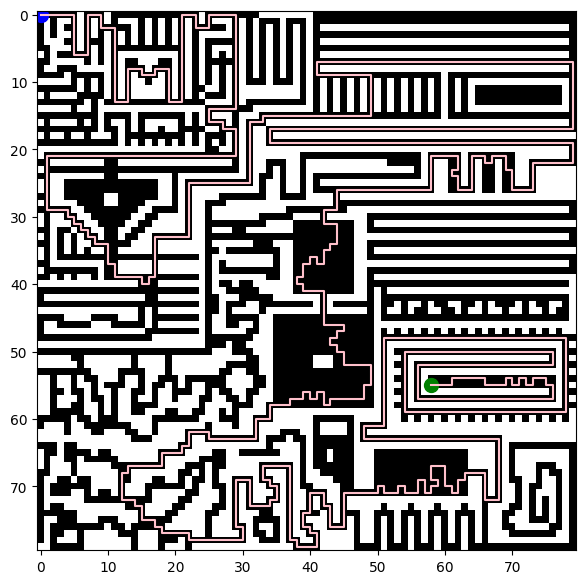

In [42]:
# Final chosen parameters from Question 16
from VisualizerHelpers import Maze as VizMaze
from Visualizer import Visualizer

group_number = "69"

final_params = {
    "easy":   {"ants": 20, "gens": 40, "q": 1600, "evap": 0.2,  "conv": 5},
    "medium": {"ants": 15, "gens": 20, "q": 2400, "evap": 0.05, "conv": 8},
    "hard":   {"ants": 20, "gens": 20, "q": 1600, "evap": 0.2,  "conv": 12},
}

for maze_name in ["easy", "medium", "hard"]:
    params = final_params[maze_name]

    maze = Maze.create_maze(f"../data/{maze_name}_maze.txt")
    spec = PathSpecification.read_coordinates(f"../data/{maze_name}_coordinates.txt")

    aco = AntColonyOptimization(
        maze,
        params["ants"],
        params["gens"],
        params["q"],
        params["evap"],
        params["conv"]
    )

    route = aco.find_shortest_route(spec)

    if route is not None:
        print(f"{maze_name.capitalize()} route size: {route.size()}")

        # separate maze object only for the visualizer
        viz_maze = VizMaze.create_maze(f"../data/{maze_name}_maze.txt")
        Visualizer.visualize_individual_path(viz_maze, route, spec)

        route.write_to_file(f"../data/{group_number}_{maze_name}.txt")
    else:
        print(f"No route found for {maze_name}")

<div>

**Answer :**

We ran the algorithm on the Easy, Medium and Hard grading mazes using the tuned parameter settings from Question 16. The resulting routes were visualized to verify that they correctly go from the start to the end without crossing walls, and then exported in the required file format.

### 2.7 Synthesis

#### Question 19

In [45]:
# Please keep your parameters for the synthesis part easily changeable here
ants_per_generation = 5
number_of_generations = 5
q = 1600
evap = 0.2
convergence_limit = 3

persist_file = "../data/my_tsp"
tsp_path = "../data/tsp_products.txt"
coordinates = "../data/hard_coordinates.txt"

# Construct optimization
maze = Maze.create_maze("../data/hard_maze.txt")
tsp_data = TSPData.read_specification(coordinates, tsp_path)
aco = AntColonyOptimization(maze, ants_per_generation, number_of_generations, q, evap, convergence_limit)

# Run optimization and write to file
tsp_data.calculate_routes(aco)
tsp_data.write_to_file(persist_file)

# Read from file and print
tsp_data2 = TSPData.read_from_file(persist_file)
print(tsp_data == tsp_data2)

# Solve TSP using your own paths file
population_size = 20
generations = 20

ga = GeneticAlgorithm(generations, population_size)
solution = ga.solve_tsp(tsp_data2)
tsp_data2.write_action_file(solution, "../data/69_actions_TSP.txt")

length = ga.route_length(solution, tsp_data2)
print("New product order:", solution)
print("New route length:", length)

Ready reading maze file ../data/hard_maze.txt
True
New product order: [0, 1, 13, 4, 3, 17, 7, 8, 9, 10, 2, 11, 14, 12, 5, 15, 6, 16]
New route length: 3289


<div>

**Answer :**

The path found in the synthesis step was different from the path found in Part 1. The main differences were both the total route length and the visiting order of the products. In Part 1, the product order was [6, 4, 0, 1, 13, 3, 15, 9, 8, 10, 16, 14, 17, 7, 11, 12, 5, 2], while in the synthesis step it became [0, 1, 13, 4, 3, 17, 7, 8, 9, 10, 2, 11, 14, 12, 5, 15, 6, 16].

The total route length also changed a lot. In Part 1, the route length was 2189, while in the synthesis step it was 3289. This means the new route is clearly worse.

The better solution is therefore the Part 1 solution, because it has the smaller total length and needs fewer movement steps overall. This makes sense, since Part 1 used the provided optimal_tsp file, while the synthesis step used distances generated by our own ACO implementation with light settings. Those estimated distances are less accurate, so the genetic algorithm was working with worse input data and therefore produced a worse final route.

## Part 3: Open Questions
### 3.1 Reflection

#### Question 20

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 21

<div style="background-color:#f1be3e">

_Write your answer here._

### 3.2 Pen and Paper

#### Question 22

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

### 3.3 Division of Work

#### Question 23

<div style="background-color:#f1be3e">


|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

### References

<div style="background-color:#f1be3e">

**If you made use of any non-course resources, cite them below.**